In [30]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
import matplotlib.ticker as mticker
from sklearn import metrics

Dataset: <br>
League - LaLiga <br>
Year(s) - 2021-25 <br>

In [3]:
# Data Collection
# Import data from csv file
df = pd.read_csv('Final_LaLiga_DataSet_All.csv')
# df

In [4]:
# Pre-Processing 
# Create new column Match_Outcome using Home_Score and Away_Score
filtered = df.loc[df['Time']=='FT']
# filtered

conditions = [
    (filtered['Home_Score'] > filtered['Away_Score']),
    (filtered['Away_Score'] > filtered['Home_Score']),
    (filtered['Home_Score'] == filtered['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']

filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')

# filtered

match_outcome_dict = dict(zip(filtered['Game_ID'].values, filtered['Match_Outcomes'].values))
# match_outcome_dict

df['Match_Outcomes'] = df['Game_ID'].map(match_outcome_dict) # assigns the new col

df.head()

C:\Users\matth\AppData\Local\Temp\ipykernel_8948\473369177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')


,Game_ID,Season,Matchweek,Game_Type,Time,Team,Home_Score,Away_Score,Home_Red_Count,Away_Red_Count,...,Away_Off_Sub_Count,Away_Def_Sub_Count,Match_URL,Event_Type,Player_1,Pos_1,Player_2,Pos_2,Note,Match_Outcomes
0,20210101,2021,1,League,3,Home,0,0,1,0,...,0,0,https://fbref.com/en/matches/e69c743a/Valencia...,Red Card,Hugo Guillamón,CM,NaN,NaN,Red Card,Home_Win
1,20210101,2021,1,League,11,Home,1,0,1,0,...,0,0,https://fbref.com/en/matches/e69c743a/Valencia...,Goal,Carlos Soler,CM,NaN,NaN,Goal,Home_Win
2,20210101,2021,1,League,46,Away,1,0,1,0,...,1,0,https://fbref.com/en/matches/e69c743a/Valencia...,Substitution,Stefan Mitrović,CB,Vitolo,AM,Offensive Sub,Home_Win
3,20210101,2021,1,League,46,Away,1,0,1,0,...,2,0,https://fbref.com/en/matches/e69c743a/Valencia...,Substitution,Carles Aleñá,CM,Jaime Mata,FW,Offensive Sub,Home_Win
4,20210101,2021,1,League,67,Away,1,0,1,0,...,2,0,https://fbref.com/en/matches/e69c743a/Valencia...,Substitution,Sandro Ramírez,FW,José Juan Macías,FW,Neutral Sub,Home_Win


In [5]:
# Pre-Processing (cont.)
# Convert Time column to usable format, 
# Note: times like 45+4 become 49, which intersect with the normal 49min datapoint (one before and after halftime), will see a small discrepancy here
#       times 90+5 become 95 with no issues
#       times FT are dropped as they directly relate the target result, ruining the model

df_filtered = df[df['Time']!='FT'] # drops 'FT' times
df_filtered['Time'] = df_filtered['Time'].apply(eval) # evals expression, ex: 45+3->48


C:\Users\matth\AppData\Local\Temp\ipykernel_8948\715974466.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Time'] = df_filtered['Time'].apply(eval) # evals expression, ex: 45+3->48


In [6]:
X = df_filtered.loc[:, ['Time', 'Home_Score', 'Away_Score', 'Home_Red_Count', 'Away_Red_Count', 
               'Home_Off_Sub_Count', 'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']]
X.shape

y = df_filtered.loc[:,'Match_Outcomes'].values
y

# Train/Test Split with 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

Find best k value

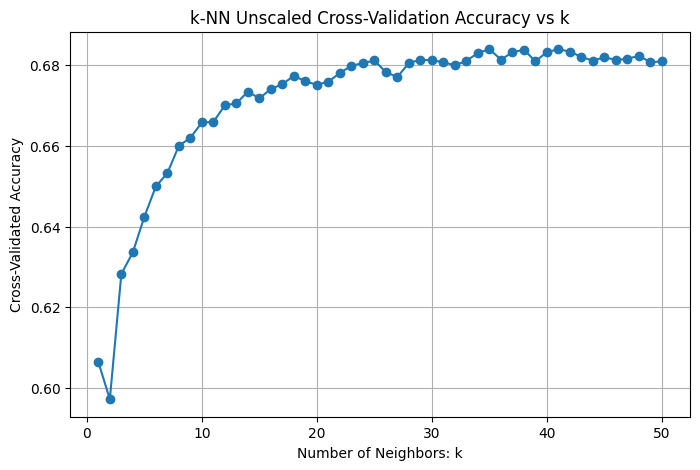

Best k from cross-validation: 35


In [7]:
k_range = range(1, 51)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Unscaled Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

In [8]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)

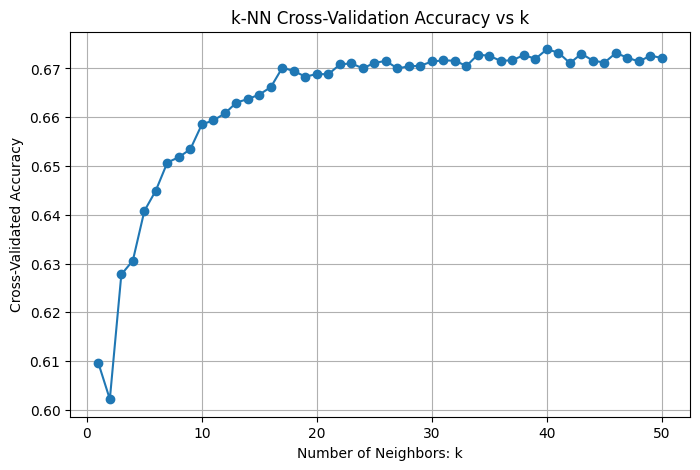

Best k from cross-validation: 40


In [9]:
# Range of k values to try
k_range = range(1, 51)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

In [10]:
# k = n_neighbors = 35 -> from best no_scaling

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=35))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=35))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,35
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [11]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.7194672131147541
Test Accuracy: 0.7081967213114754

k-NN with StandardScaler:
Training Accuracy: 0.7200136612021858
Test Accuracy: 0.7054644808743169


Confusion Matrix from pipeline_no_scaling:


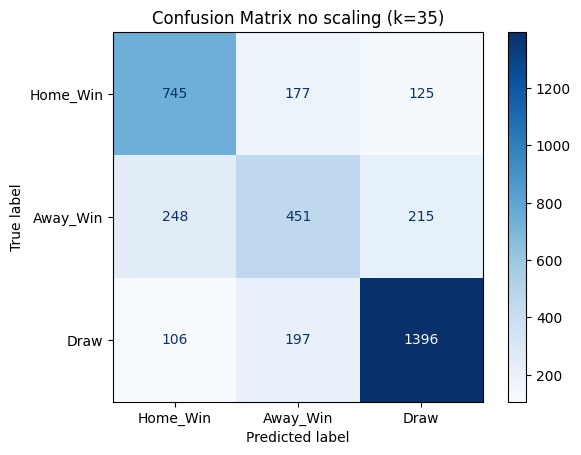

[[ 745  177  125]
 [ 248  451  215]
 [ 106  197 1396]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.68      0.71      0.69      1047
    Away_Win       0.55      0.49      0.52       914
        Draw       0.80      0.82      0.81      1699

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.70      0.71      0.71      3660

Confusion Matrix from pipeline_with_scaling:


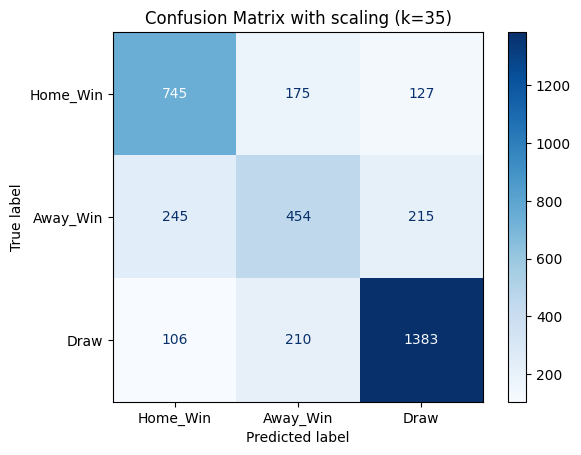

[[ 745  175  127]
 [ 245  454  215]
 [ 106  210 1383]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.68      0.71      0.70      1047
    Away_Win       0.54      0.50      0.52       914
        Draw       0.80      0.81      0.81      1699

    accuracy                           0.71      3660
   macro avg       0.67      0.67      0.67      3660
weighted avg       0.70      0.71      0.70      3660



In [12]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={35})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={35})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

In [13]:
# k = n_neighbors = 40 -> from best with_scaling

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=40))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=40))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,40
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [14]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.7169398907103826
Test Accuracy: 0.7030054644808743

k-NN with StandardScaler:
Training Accuracy: 0.7163934426229508
Test Accuracy: 0.7013661202185792


Confusion Matrix from pipeline_no_scaling:


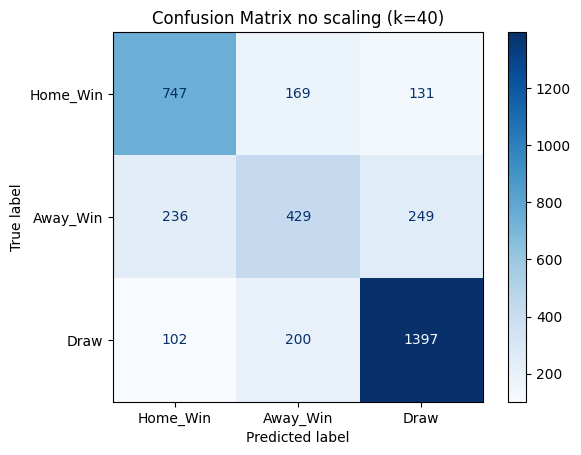

[[ 747  169  131]
 [ 236  429  249]
 [ 102  200 1397]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.69      0.71      0.70      1047
    Away_Win       0.54      0.47      0.50       914
        Draw       0.79      0.82      0.80      1699

    accuracy                           0.70      3660
   macro avg       0.67      0.67      0.67      3660
weighted avg       0.70      0.70      0.70      3660

Confusion Matrix from pipeline_with_scaling:


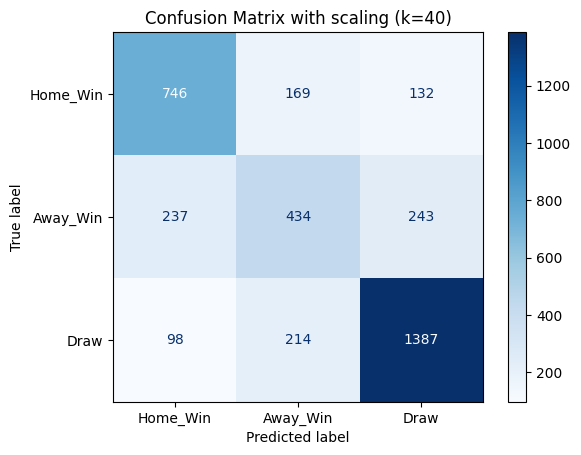

[[ 746  169  132]
 [ 237  434  243]
 [  98  214 1387]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.69      0.71      0.70      1047
    Away_Win       0.53      0.47      0.50       914
        Draw       0.79      0.82      0.80      1699

    accuracy                           0.70      3660
   macro avg       0.67      0.67      0.67      3660
weighted avg       0.70      0.70      0.70      3660



In [15]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={40})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={40})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

In [16]:
# k = n_neighbors = 5 -> worse num for comparison

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=5))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=5))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [17]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.769672131147541
Test Accuracy: 0.7073770491803278

k-NN with StandardScaler:
Training Accuracy: 0.7705601092896175
Test Accuracy: 0.7081967213114754


Confusion Matrix from pipeline_no_scaling:


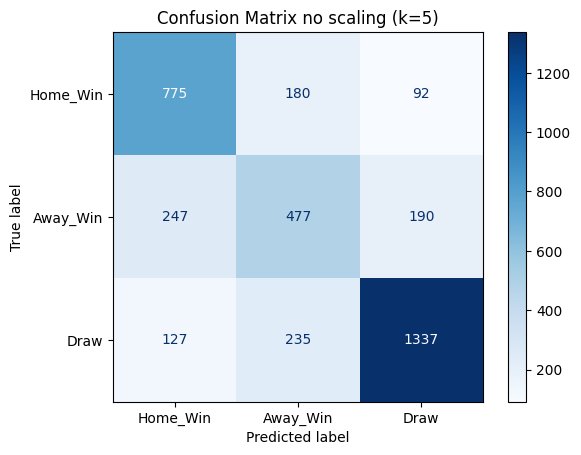

[[ 775  180   92]
 [ 247  477  190]
 [ 127  235 1337]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.67      0.74      0.71      1047
    Away_Win       0.53      0.52      0.53       914
        Draw       0.83      0.79      0.81      1699

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.71      0.71      0.71      3660

Confusion Matrix from pipeline_with_scaling:


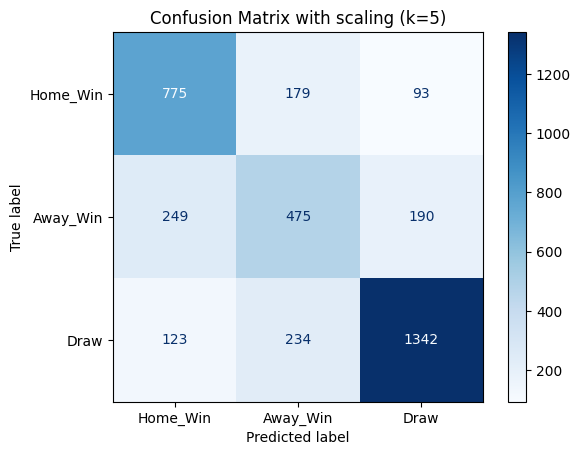

[[ 775  179   93]
 [ 249  475  190]
 [ 123  234 1342]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.68      0.74      0.71      1047
    Away_Win       0.53      0.52      0.53       914
        Draw       0.83      0.79      0.81      1699

    accuracy                           0.71      3660
   macro avg       0.68      0.68      0.68      3660
weighted avg       0.71      0.71      0.71      3660



In [18]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={5})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={5})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

In [19]:
# k = n_neighbors = 21 -> worse num for comparison

pipeline_no_scaling2 = Pipeline([('knn', KNeighborsClassifier(n_neighbors=21))])

pipeline_with_scaling2 = Pipeline([('scaler', StandardScaler()),
                                  ('knn', KNeighborsClassifier(n_neighbors=21))])

pipeline_no_scaling2.fit(X_train, y_train)

pipeline_with_scaling2.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [20]:
print("k-NN without scaling:")
# Write your code here.
train_acc_no_scaling2 = pipeline_no_scaling2.score(X_train, y_train)
test_acc_no_scaling2 = pipeline_no_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_no_scaling2}\nTest Accuracy: {test_acc_no_scaling2}')

print("\nk-NN with StandardScaler:")
# Write your code here.
train_acc_scaling2 = pipeline_with_scaling2.score(X_train, y_train)
test_acc_scaling2 = pipeline_with_scaling2.score(X_test, y_test)
print(f'Training Accuracy: {train_acc_scaling2}\nTest Accuracy: {test_acc_scaling2}')

k-NN without scaling:
Training Accuracy: 0.7323087431693989
Test Accuracy: 0.7049180327868853

k-NN with StandardScaler:
Training Accuracy: 0.7317622950819672
Test Accuracy: 0.703551912568306


Confusion Matrix from pipeline_no_scaling:


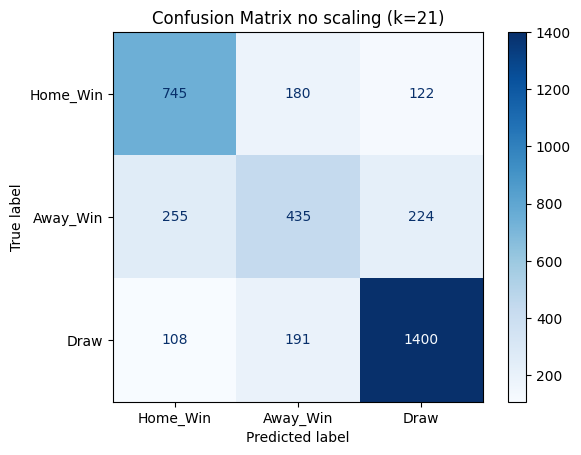

[[ 745  180  122]
 [ 255  435  224]
 [ 108  191 1400]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.67      0.71      0.69      1047
    Away_Win       0.54      0.48      0.51       914
        Draw       0.80      0.82      0.81      1699

    accuracy                           0.70      3660
   macro avg       0.67      0.67      0.67      3660
weighted avg       0.70      0.70      0.70      3660

Confusion Matrix from pipeline_with_scaling:


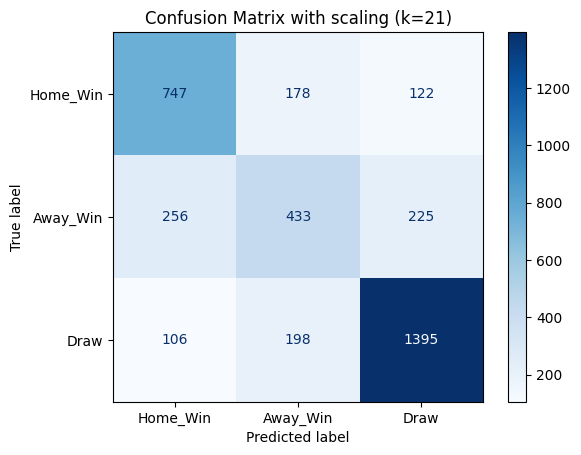

[[ 747  178  122]
 [ 256  433  225]
 [ 106  198 1395]]
Classification Report:
              precision    recall  f1-score   support

    Home_Win       0.67      0.71      0.69      1047
    Away_Win       0.54      0.47      0.50       914
        Draw       0.80      0.82      0.81      1699

    accuracy                           0.70      3660
   macro avg       0.67      0.67      0.67      3660
weighted avg       0.70      0.70      0.70      3660



In [21]:
y_pred = pipeline_no_scaling2.predict(X_test)
y_pred2 = pipeline_with_scaling2.predict(X_test)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y_test, y_pred2)
print('Confusion Matrix from pipeline_no_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix no scaling (k={21})")
plt.grid(False)
plt.show()
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Home_Win", "Away_Win", "Draw"]))

print('Confusion Matrix from pipeline_with_scaling:')
# Confusion Matrix no Scaling
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Home_Win", "Away_Win", "Draw"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with scaling (k={21})")
plt.grid(False)
plt.show()
print(cm2)

print("Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Home_Win", "Away_Win", "Draw"]))

<h3>Feature Selection</h3>
<br>
All feature's vs time

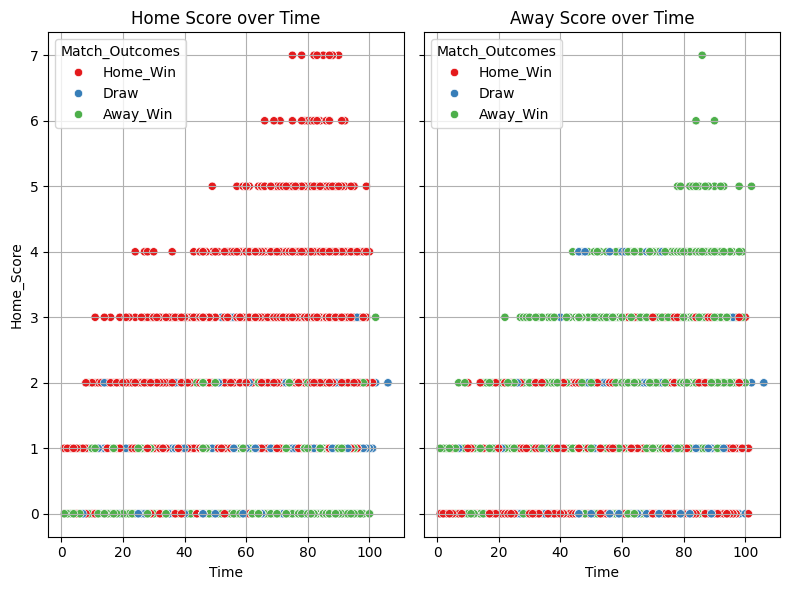

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# Plot 1 (Left side)
sns.scatterplot(data=df_filtered, x="Time", y="Home_Score", hue="Match_Outcomes", palette="Set1", ax=axes[0])
axes[0].set_title("Home Score over Time")
axes[0].grid(True)

# Plot 2 (Right side)
sns.scatterplot(data=df_filtered, x="Time", y="Away_Score", hue="Match_Outcomes", palette="Set1", ax=axes[1])
axes[1].set_title("Away Score over Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()

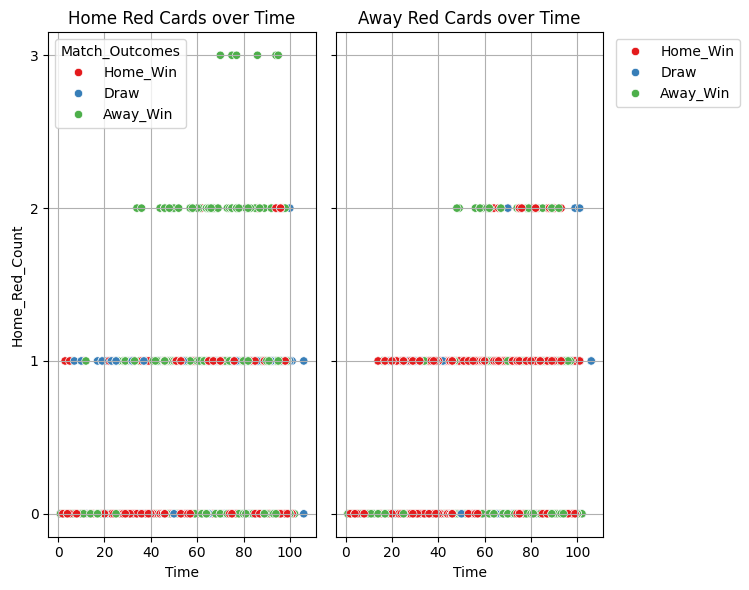

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Left side)
sns.scatterplot(data=df_filtered, x="Time", y="Home_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0])
axes[0].set_title("Home Red Cards over Time")
axes[0].grid(True)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0].yaxis.set_major_formatter(integer_formatter)

# Plot 2 (Right side)
sns.scatterplot(data=df_filtered, x="Time", y="Away_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1])
axes[1].set_title("Away Red Cards over Time")
axes[1].grid(True)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[1].yaxis.set_major_formatter(integer_formatter)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))


plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to prevent the external legend from being cut off
plt.show()

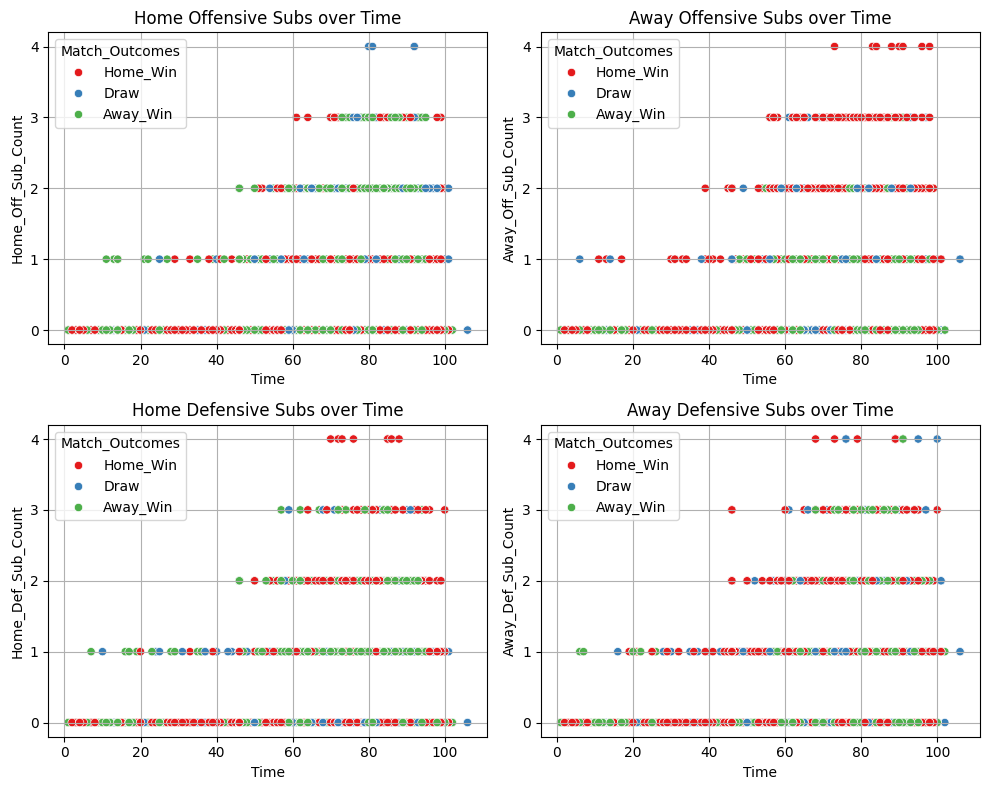

In [34]:
# Create a single figure with 2 rows and 2 columns (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Top Left)
sns.scatterplot(data=df_filtered, x="Time", y="Home_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Home Offensive Subs over Time")
axes[0, 0].grid(True)
axes[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 0].yaxis.set_major_formatter(integer_formatter)


# Plot 2 (Top Right)
sns.scatterplot(data=df_filtered, x="Time", y="Away_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Away Offensive Subs over Time")
axes[0, 1].grid(True)
axes[0, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 1].yaxis.set_major_formatter(integer_formatter)

# Plot 3 (Bottom Left) - Corrected Title
sns.scatterplot(data=df_filtered, x="Time", y="Home_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Home Defensive Subs over Time")
axes[1, 0].grid(True)
axes[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[1, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 4 (Bottom Right) - Corrected Title
sns.scatterplot(data=df_filtered, x="Time", y="Away_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 1])
axes[1, 1].set_title("Away Defensive Subs over Time")
axes[1, 1].grid(True)
axes[1, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[1, 1].yaxis.set_major_formatter(integer_formatter)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the single combined figure
plt.show()

Score/RedCards vs Substitutions

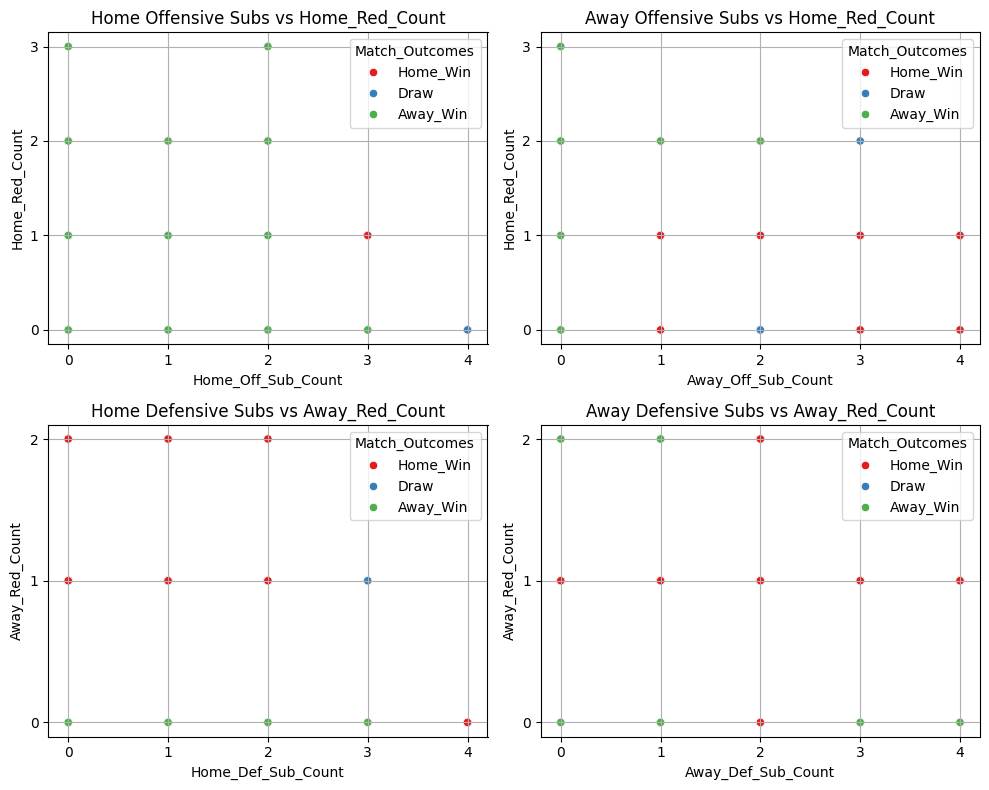

In [31]:
# Create a single figure with 2 rows and 2 columns (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Top Left)
sns.scatterplot(data=df_filtered, y="Home_Red_Count", x="Home_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Home Offensive Subs vs Home_Red_Count")
axes[0, 0].grid(True)
axes[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set x-axis to integers
axes[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 0].xaxis.set_major_formatter(integer_formatter)
axes[0, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 2 (Top Right)
sns.scatterplot(data=df_filtered, y="Home_Red_Count", x="Away_Off_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Away Offensive Subs vs Home_Red_Count")
axes[0, 1].grid(True)
axes[0, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].xaxis.set_major_formatter(integer_formatter)
axes[0, 1].yaxis.set_major_formatter(integer_formatter)

# Plot 3 (Bottom Left) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Red_Count", x="Home_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Home Defensive Subs vs Away_Red_Count")
axes[1, 0].grid(True)
axes[1, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].xaxis.set_major_formatter(integer_formatter)
axes[1, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 4 (Bottom Right) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Red_Count", x="Away_Def_Sub_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 1])
axes[1, 1].set_title("Away Defensive Subs vs Away_Red_Count")
axes[1, 1].grid(True)
axes[1, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].xaxis.set_major_formatter(integer_formatter)
axes[1, 1].yaxis.set_major_formatter(integer_formatter)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the single combined figure
plt.show()

Score vs Red_Cards

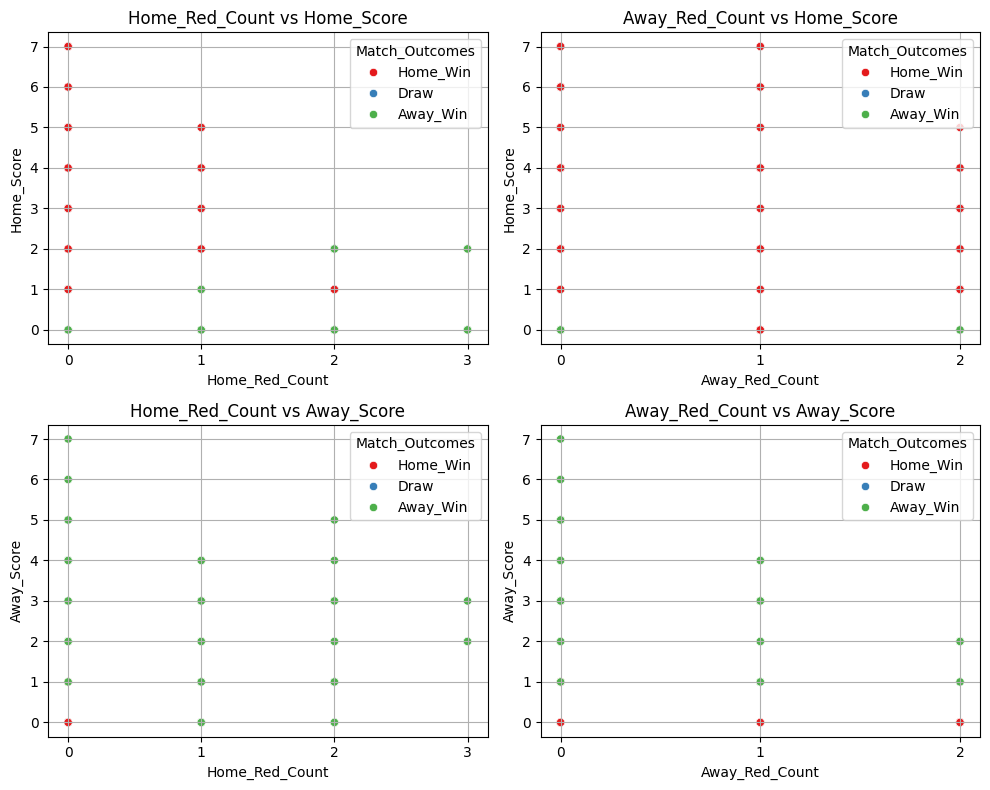

In [33]:
# Create a single figure with 2 rows and 2 columns (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# Define a common formatter for integer display
integer_formatter = mticker.FormatStrFormatter('%d')

# Plot 1 (Top Left)
sns.scatterplot(data=df_filtered, y="Home_Score", x="Home_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Home_Red_Count vs Home_Score")
axes[0, 0].grid(True)
axes[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set x-axis to integers
axes[0, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True)) # Set y-axis to integers
axes[0, 0].xaxis.set_major_formatter(integer_formatter)
axes[0, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 2 (Top Right)
sns.scatterplot(data=df_filtered, y="Home_Score", x="Away_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("Away_Red_Count vs Home_Score")
axes[0, 1].grid(True)
axes[0, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0, 1].xaxis.set_major_formatter(integer_formatter)
axes[0, 1].yaxis.set_major_formatter(integer_formatter)

# Plot 3 (Bottom Left) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Score", x="Home_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Home_Red_Count vs Away_Score")
axes[1, 0].grid(True)
axes[1, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 0].xaxis.set_major_formatter(integer_formatter)
axes[1, 0].yaxis.set_major_formatter(integer_formatter)

# Plot 4 (Bottom Right) - Corrected Title
sns.scatterplot(data=df_filtered, y="Away_Score", x="Away_Red_Count", hue="Match_Outcomes", palette="Set1", ax=axes[1, 1])
axes[1, 1].set_title("Away_Red_Count vs Away_Score")
axes[1, 1].grid(True)
axes[1, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1, 1].xaxis.set_major_formatter(integer_formatter)
axes[1, 1].yaxis.set_major_formatter(integer_formatter)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the single combined figure
plt.show()